# One dimensional dummy problem

## Problem Statement

The model will have diffusion of hydrogen gas and convection with a flow speed that is calculated from the pressure. The battery will be on the domain $\Omega = (0,L)$, where $L$ is the length of the battery. The left boundary will be the inflow of hydrogen gas, and the right boundary will be the outflow of hydrogen gas. Since we now also model the pressure we can assume pure hydrogen gas everywhere, and adjust the gas absorption with its intended pressure dependency. It also assumes constant temperature, and ideal gas law: $p=\rho_g RT$. The model also takes into account viscous dissipation of a poreous medium. It is summarized in the following system of equations:
\begin{equation}
\left\{\begin{aligned}
\rho_g \partial_t v &=-RT\partial_x\rho_g-\rho_g v \partial_x v+\mu\partial_x^2 v -S\\
\epsilon\partial_t\rho_g&=-\partial_x (\rho_g v)+ \mu_\epsilon\partial_x^2\rho_g-\dot m \\
(1-\epsilon)\partial_t \rho_s &= \dot m 
\end{aligned}\right.
\end{equation}
Where $\rho_g$ is the density of H2 in the air, now seen as a true density, instead of a ratio. $\rho_s$ is the amount of hydrogen in the solid Metal Organic Framework, $v$ is the flow speed, $\mu$ is the viscosity of the gas, and $\mu_\epsilon$ is the diffusion coefficient, this is required numerically to avoid instabilities and oscilations (even when using upwind schemes). The absorption and viscous dissipation are given by:
\begin{align}
    \dot m &= A\log(\frac{p_g}{p_{eq,a}})(\rho_{sat}-\rho_s)\\
    S &= \frac{\mu}{K}v
\end{align}
under IC:
\begin{equation}
\left\{ \begin{aligned}
\rho_g(x,0) &= 1 \\
v(x,0) &= 0
\end{aligned}\right.
\end{equation}
(the solid doesn't need a boundary condition since it is not really coupled to its surroundings), and BC:
\begin{equation}
\left\{\begin{aligned}
    v(L,t) &= 0\\
\rho_g(0,t) &= 2-e^{-10t} \\
\partial_x v(0,t) &= 0 \\
\end{aligned}\right.
\end{equation}
where we use a steep increase in density at the inlet to simulate a step function, since a discontinuity gives extremely low initial time steps. The BC for the velocity is a no-slip condition at the outlet, and a zero gradient at the inlet. 

We will expand $\rho_g$, $\rho_s$, and $v$ as:
\begin{equation}
    \begin{aligned}
         v(x,t) &= \sum_j v^j(t) \phi^j(x) \\
    \rho_g(x,t) &= \sum_i \rho_{g}^i(t) \phi^i(x) \\
    \rho_s(x,t) &= \sum_i \rho_{s}^i(t) \phi^i(x) \\
    \end{aligned}
\end{equation}
with our solutionvector:

\begin{equation}
    \mathbf u = \begin{pmatrix}
        v^1        \\ \vdots \\ v^{N_2}      \\
        \rho_{g}^1 \\ \vdots \\ \rho_{g}^{N_1} \\ 
        \rho_{s}^1 \\ \vdots \\ \rho_{s}^{N_1} \\ 
    \end{pmatrix}
\end{equation}

we will also need an expansion of the mass transfer term:
\begin{equation}
    \dot m(x,t) = \sum_i \dot m^i(t) \phi^i(x)
\end{equation}
which we will approximate at the terms using our knowledge that on nodes the only non-zero basis function is the one corresponding to that node, so we can approximate the mass transfer term as:
\begin{equation}
    \dot m^i(t) = A_a\log\left(\frac{RT \rho_g^i(t)}{p_{eq,a}}\right)(\rho_{sat}-\rho_s^i(t))
\end{equation}

### Mathematical Discretizations

If we look at the top part equation and multiply by test functions $\phi^k$, integrate and expand as above, we get:

\begin{equation}
    \sum_j\left(\sum_i\rho_i\int_\Omega \phi^i\phi^j\phi^k\,dx\right)(\partial_t \mathbf{u})
\end{equation}

Which becomes:

\begin{equation}
    M\dot{\mathbf{u}}
\end{equation}

where row $k$ and column $j$ correspond to:

\begin{equation}
    (M_v)_{kj} = \sum_i\rho_i\int \phi^i\phi^j\phi^k\,dx
\end{equation}
I plan on precalculating the integrals into a tensor:

\begin{equation}
    T_{ijk} = \int \phi^i\phi^j\phi^k\,dx
\end{equation}
simplifying:
\begin{equation}
(M_v)_{kj}=\sum_i \rho_iT_{ijk}
\end{equation}

For the RHS of the first equation we get (after integration and multiplying by $\phi^k$) term for term:

\begin{equation}
\begin{aligned}
    -RT\sum_i\left(\int \phi^k\phi^i\,dx\right)\rho_i &= P\mathbf{\rho}\\
    -\mu\sum_i\left(\int\partial_x\phi^k\partial_x\phi^i\,dx\right) v_i &= D\mathbf{v} 
    % & \text{negative sign due to integration by parts}
    \\
    -\frac{\mu}{K}\sum_i\left(\int \phi^k\phi^i \, dx \right)v_i&= S \mathbf{v}
\end{aligned}
\end{equation}

For the convection term we have:
\begin{equation}
    C^{v}_j = \int_\Omega \phi^k \rho_g v \partial_x v \, dx
\end{equation}
which we will approximate using a quadrature rule.


Giving us:

\begin{equation}
    M_v(\rho) \dot{\mathbf{v}}=P\mathbf{\rho}+D\mathbf{v}+S\mathbf{v}+C^{v}(\mathbf{v},\mathbf{\rho})
\end{equation}


Now for the conservation of mass equation, the LHS becomes:
\begin{equation}
\sum_i\left(\int\phi^i\phi^k\,dx\right)(\partial_t\rho_i)=M_\rho\dot{\mathbf{u}}
\end{equation}

and the first term in the RHS becomes:
\begin{equation}
    -\int\phi^k\partial_x(\rho v)dx = -\left[ \phi^k\rho v\right]_{x\in\delta\Omega}+\int(\partial_x\phi^k)v \rho\, dx =\mathbf{C}^{\rho_g}(\mathbf{v},\mathbf{\rho})
\end{equation}

The diffusion familiarly becomes:
\begin{equation}
    \mu_\epsilon\sum_i\left(\int\partial_x\phi^k\partial_x\phi^i\,dx\right) \rho_i = D_\epsilon \mathbf{\rho}
\end{equation}

The mass transfer term is given by:
\begin{equation}
\begin{aligned}
    \int\phi^k\dot m dx &= \int \phi^k \sum_i \dot m^i(t) \phi^i(x) dx \\
    &= \sum_i \dot m^i(t) \int \phi^k \phi^i dx \\
    &= M_{{\rho_g}} \dot{\mathbf{m}}
\end{aligned}
\end{equation}
where:
\begin{equation}
    \dot{m}^i = A_a\log\left(\frac{RT \rho_g^i(t)}{p_{eq,a}}\right)(\rho_{sat}-\rho_s^i(t))
\end{equation}

### IMEX Scheme

I want to use a similar IMEX Scheme as I did in section 1.
Previously I had solved one with an IMEX scheme, where all linear parts were taken implicit, and non-linear parts explicit. Having

\begin{equation}
\begin{aligned}
M_v(\rho_g)\dot{v}&=P\rho_g+Dv + Sv + C^{v}(\mathbf{v},\mathbf{\rho})\\
\epsilon \,M_{\rho_g}\dot{\rho}_g&=D_\epsilon \rho_g-M_{{\rho_g}}\dot{\mathbf{m}}+C^{\rho_g}(\mathbf{v},\mathbf{\rho})\\
(1-\epsilon)M_{\rho_s}\dot{\rho}_s&=M_{{\rho_g}}\dot{\mathbf{m}}
\end{aligned}
\end{equation}
which can be summarized into:
\begin{equation}
\begin{aligned}
    M(u)\dot{u} &= L[u]+N(u) \\
    N(u) &= C(u)+M_m\begin{pmatrix}
    0 \\ -\dot{\mathbf{m}}(u) \\ \dot{\mathbf{m}}(u)
    \end{pmatrix} \\
    L &= \begin{pmatrix}
    D+S & P & 0 \\
    0 & D_\epsilon & 0 \\
    0 & 0 & 0
    \end{pmatrix} \\
    M_m &= \begin{pmatrix}
    0 & 0 & 0 \\
    0 & M_{{\rho_g}} & 0 \\
    0 & 0 & M_{{\rho_g}}
    \end{pmatrix}\\
    M &= \begin{pmatrix}
    M_v(\rho) & 0 & 0 \\
    0 & M_{\rho_g} & 0 \\
    0 & 0 & M_{\rho_s}
    \end{pmatrix}
\end{aligned} 
\end{equation}

Is it now again posible to IMEX scheme like:

\begin{equation}
\begin{aligned}
M_v(\rho^n)\frac{v^{n+1}-v^n}{\Delta t}&=P\rho^{n+1}+Dv^{n+1} \\
M_{\rho}\frac{\rho^{n+1}-\rho^n}{\Delta t}&=N(\rho^n, v^n)+BF^n
\end{aligned}
\end{equation}

which gives:

\begin{equation}
\begin{aligned}
\frac{M_{\rho}}{\Delta t}{\rho^{n+1}}&=N(\rho^n, v^n)+BF^n+\frac{M_{\rho}}{\Delta t}\rho^n \\
\left[\frac{M_v(\rho^n)}{\Delta t}-D\right]v^{n+1}-P\rho^{n+1}&=\frac{M_v(\rho^n)}{\Delta t}v^n
\end{aligned}
\end{equation}

which gives:

\begin{equation}
    Au^{n+1}=Bu^n+C
\end{equation}

where:

\begin{equation}
\begin{aligned}
    A(\mathbf{u}^n) &= \begin{pmatrix}
    \frac{M_v(\rho_g^n)}{\Delta t}-D-S & -P & 0 \\ 
    0 & \frac{M_{\rho_g}}{\Delta t}-D_\epsilon & 0 \\
    0 & 0 & \frac{M_{\rho_s}}{\Delta t}
    \end{pmatrix} \\
    B &= \begin{pmatrix}
    \frac{M_{\rho}}{\Delta t} & 0 \\
    0 & \frac{M_v(\rho^n)}{\Delta t}
    \end{pmatrix}\\
    C &= \begin{pmatrix}
        C^{v}(\mathbf{v}^n,\boldsymbol{\rho}^n) \\ C^{\rho_g}(\mathbf{v}^n,\boldsymbol{\rho}^n) \\0 
    \end{pmatrix}\\
    (M_{\rho})_{ij}&=\int \phi^i\phi^j\,dx \\
    P_{ij} &= -RT\int\phi^i\partial_x\phi^j\,dx \\
    D_{ij} &= -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx\\
    (M_v(\rho^n))_{kj}&=\sum_i\rho_i T_{kij} \\
    T_{ijk} &= \int \phi^i\phi^j\phi^k\,dx\\
    (N(\rho^n, v^n))_k&=-\big[\phi^k\rho v\big]_{\delta \Omega}+\int\partial_x(\phi^k)v\rho\,dx\\
\end{aligned}
\end{equation}

In [192]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra

## Definitions

In [193]:
# constants
R_u = 8.314462618       # J/(mol*K)
M_H2 = 2.01588e-3       # kg/mol
R = R_u / M_H2       # J/(kg*K)
T = 300.0           # K
μ = 8.4e-6          # Pa*s = kg/(m*s)
μϵ = 1.0e-9         # Pa*s = kg/(m*s)  for stabilizing purposes, non-physical, should be as small as possible
C_a = 59.187        # s^-1
p_ref = 1.0e6       # 1MPA
ρ_sat = 7259.0      # kg/m^3
ρ_e = 7164.0        # kg/m^3    initial density solid
E_a = 21179.6       # J/mol
K = 1.0e-9          # m^2, permeability

ϵ = 0.4             # unitless, measure of porosity
A_hoffman = 10.7    # unitless  used for calculating p_eq, the equilibrium pressure, different for desorption
B_hoffman = 3704.6  # K used for calculating p_eq, the equilibrium pressure

# A = C_a * exp(-E_a/(R*T)) * (p_ref/(R*T))^A_t
A_a = C_a * exp(-E_a/(R_u*T))
p_eqa = p_ref * exp(A_hoffman-B_hoffman/T)

p_in = 4.0 * p_eqa
ρ_in = p_in / (R * T)
ρ_eq = p_eqa / (R * T)

println("A_a = ", A_a, " s^-1")
println("p_eqa = ", p_eqa, " Pa")

A_a = 0.01215073059348989 s^-1
p_eqa = 192306.14595250844 Pa


In [194]:
ρ_in

0.6216735525612657

In [195]:
ρ_eq

0.15541838814031642

In [196]:
# Time integration parameters
dt = 1e-4
dt_save = 1e-1
T1 = 3.0;

# spacial discretization parameters
L = 0.5     # length of the domain in x-direction
w = 0.2     # width of the domain in y-direction box is from (0, -w) to (L, w)
h1 = 0.1    # width of the inlet in y-direction. Inlet is from (0, -h1) to (0, h1)
Nx = 24
Ny = 16

hx = L / Nx
hy = 2*w / Ny

save_every = Int(round(dt_save / dt))  # = 100 steps
nsteps = Int(round(T1 / dt_save))


name = "a. two dimensional";

## grid

In [197]:
# generates grid
grid = generate_grid(
    Quadrilateral, 
    (Nx, Ny), 
    Vec((0.0,-w)), 
    Vec((L,w))
)

# generate the same 
qr = QuadratureRule{RefQuadrilateral}(3)
fr = FacetQuadratureRule{RefQuadrilateral}(2)

# rho, rho_s, and v
ip_rho = Lagrange{RefQuadrilateral, 1}()
cellvalues_rho = CellValues(qr, ip_rho);

ip_rho_s = Lagrange{RefQuadrilateral, 1}()
cellvalues_rho_s = CellValues(qr, ip_rho_s);

ip_v = Lagrange{RefQuadrilateral, 1}()^2
cellvalues_v = CellValues(qr, ip_v);

# facet interpolation for the boundary conditions
ip_f = Lagrange{RefQuadrilateral, 1}()
fqr = FacetQuadratureRule{RefQuadrilateral}(1)
facetvalues = FacetValues(Float64, fqr, ip_f)
facetvalues_v = FacetValues(fqr, ip_v)          # because the velocity is a vector

#create left_slit
addfacetset!(
    grid,
    "left_slit",
    x -> abs(x[1]) < 1e-8 && -h1-1e-8 <= x[2] <= h1+1e-8
)
    
# other boundaries
addfacetset!(
    grid,
    "no_slip_boundaries",
    x ->
        (
            abs(x[1]) < 1e-8 &&
            (x[2] <= -h1 || x[2] >= h1)
        ) ||                            # left boundary excluding the slit
        abs(x[1] - L) < 1e-8 ||         # right boundary
        abs(x[2] + w) < 1e-8 ||         # bottom boundary
        abs(x[2] - w) < 1e-8            # top boundary
)

Grid{2, Quadrilateral, Float64} with 384 Quadrilateral cells and 425 nodes

In [198]:
getfacetset(grid, "left_slit")

OrderedCollections.OrderedSet{FacetIndex} with 8 elements:
  FacetIndex((97, 4))
  FacetIndex((121, 4))
  FacetIndex((145, 4))
  FacetIndex((169, 4))
  FacetIndex((193, 4))
  FacetIndex((217, 4))
  FacetIndex((241, 4))
  FacetIndex((265, 4))

In [199]:
# degree of freedom handler
dh = DofHandler(grid)
add!(dh, :v,   ip_v)
add!(dh, :rho, ip_rho)
add!(dh, :rho_s, ip_rho_s)
close!(dh);

In [200]:
# # below only to find the dofs of the inlet boundary conditions, 
# ch_rho_left = ConstraintHandler(dh)

# dummy_rho = Dirichlet(
#     :rho,
#     left,
#     (x, t) -> 0.0,
# )

# add!(ch_rho_left, dummy_rho)
# close!(ch_rho_left)

# inlet_rho_dofs = copy(ch_rho_left.prescribed_dofs)

# ch_v_left = ConstraintHandler(dh)

# dummy_v = Dirichlet(
#     :v,
#     left,
#     (x, t) -> 0.0,
# )

# add!(ch_v_left, dummy_v)
# close!(ch_v_left)

# inlet_v_dofs = copy(ch_v_left.prescribed_dofs);

In [201]:
# linear constraint handler
ch_lin = ConstraintHandler(dh)

τ = 0.1
no_slip = Dirichlet(
    :v,
    getfacetset(grid, "no_slip_boundaries"),
    (x, t) -> Vec((0.0, 0.0))
)
rho_inlet = Dirichlet(
    :rho,
    getfacetset(grid, "left_slit"),
    (x, t) -> ρ_eq + (ρ_in-ρ_eq) * (1.0 - exp(-t/τ))
)
add!(ch_lin, no_slip)
add!(ch_lin, rho_inlet)
close!(ch_lin)

update!(ch_lin, 0.0)

In [202]:
# for debugging purpuses

const rho_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho)]
    for cell in CellIterator(dh)
]...)))

const v_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:v)]
    for cell in CellIterator(dh)
]...)));

const rho_s_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho_s)]
    for cell in CellIterator(dh)
]...)));

$$(M_{\rho})_{ij}=\int \phi^i\phi^j\,dx$$

In [203]:
function doassemble_M_rho!(
    M_rho::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rho_s::CellValues,
    dh::DofHandler
    )

    # number of basis functions per field, initialize Me
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rho_s  = getnbasefunctions(cellvalues_rho_s)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(M_rho)
    rho_dofs = dof_range(dh, :rho)
    rhos_dofs  = dof_range(dh, :rho_s)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for rho
        cell_dofs = celldofs(cell)
        fill!(Me,0)
        
        # rho
        Ferrite.reinit!(cellvalues_rho, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)
            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q_point, i)
                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q_point, j)
                    # pim pam pet
                    Me[rho_dofs[i], rho_dofs[j]] += ϵ * psi_i * psi_j * dx
                end
            end
        end

        # rhos
        Ferrite.reinit!(cellvalues_rho_s, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho_s)
            dx = getdetJdV(cellvalues_rho_s, q_point)
            for i in 1:n_basefuncs_rho_s
                psi_i = shape_value(cellvalues_rho_s, q_point, i)
                for j in 1:n_basefuncs_rho_s
                    psi_j = shape_value(cellvalues_rho_s, q_point, j)
                    # pim pam pet
                    Me[rhos_dofs[i], rhos_dofs[j]] += (1-ϵ) * psi_i * psi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Me)
    end
    return M_rho
end


doassemble_M_rho! (generic function with 1 method)

In [204]:
test_cell = first(CellIterator(dh))
ndofs_cell = length(celldofs(test_cell))
cell_dofs = celldofs(test_cell)

v_dofs = dof_range(dh, :v)
cell_dofs[v_dofs]

Ferrite.reinit!(cellvalues_v, test_cell)
for q in 1:getnquadpoints(cellvalues_v)
    dx = getdetJdV(cellvalues_v, q)
    for i in 1:getnbasefunctions(cellvalues_v)
        psi_i = shape_value(cellvalues_v, q, i)
        println("q = ", q, ", i = ", i, ", psi_i = ", psi_i, ", dx = ", dx)
    end

    dpsi_1 = shape_gradient(cellvalues_v, q, 1)
    println("q = ", q, ", dpsi_1 = ", dpsi_1)

    break
end

q = 1, i = 1, psi_i = [0.7872983346207417, 0.0], dx = 4.018775720164617e-5
q = 1, i = 2, psi_i = [0.0, 0.7872983346207417], dx = 4.018775720164617e-5
q = 1, i = 3, psi_i = [0.09999999999999994, 0.0], dx = 4.018775720164617e-5
q = 1, i = 4, psi_i = [0.0, 0.09999999999999994], dx = 4.018775720164617e-5
q = 1, i = 5, psi_i = [0.012701665379258296, 0.0], dx = 4.018775720164617e-5
q = 1, i = 6, psi_i = [0.0, 0.012701665379258296], dx = 4.018775720164617e-5
q = 1, i = 7, psi_i = [0.09999999999999994, 0.0], dx = 4.018775720164617e-5
q = 1, i = 8, psi_i = [0.0, 0.09999999999999994], dx = 4.018775720164617e-5
q = 1, dpsi_1 = [-42.59032006179561 -35.4919333848296; 0.0 0.0]


$$D_{ij} = -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [205]:
function doassemble_D!(
    D::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    De = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(D)
    v_dofs = dof_range(dh, :v)
    
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(De,0)
        
        Ferrite.reinit!(cellvalues_v, cell)

        for q_point in 1:getnquadpoints(cellvalues_v)
            dx = getdetJdV(cellvalues_v, q_point)

            for i in 1:n_basefuncs_v
                dpsi_i = shape_gradient(cellvalues_v, q_point, i)

                for j in 1:n_basefuncs_v
                    dpsi_j = shape_gradient(cellvalues_v, q_point, j)

                    De[v_dofs[i], v_dofs[j]] += -μ * dpsi_i ⊡ dpsi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, De)
    end
    return D
end


doassemble_D! (generic function with 1 method)

$$D^p_{ij} = -\epsilon\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [206]:
function doassemble_Dp!(
    Dp::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Dpe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(Dp)
    rho_dofs = dof_range(dh, :rho)
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Dpe,0)
        
        Ferrite.reinit!(cellvalues_rho, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                dpsi_i = shape_gradient(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)

                    Dpe[rho_dofs[i], rho_dofs[j]] += -μϵ * dot(dpsi_i, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Dpe)
    end
    return Dp
end


doassemble_Dp! (generic function with 1 method)

$$P_{ij} = -RT\int\phi^i\partial_x\phi^j\,dx$$

In [207]:
function doassemble_P!(
    P::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    cellvalues_ρ:: CellValues,
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_ρ  = getnbasefunctions(cellvalues_ρ)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Pe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(P)
    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Pe,0)

        Ferrite.reinit!(cellvalues_v, cell)
        Ferrite.reinit!(cellvalues_ρ, cell)

        for q in 1:getnquadpoints(cellvalues_v)

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v

                phi_k = shape_value(cellvalues_v, q, k)

                for j in 1:n_basefuncs_ρ

                    dpsi_j = shape_gradient(cellvalues_ρ, q, j)

                    Pe[v_dofs[k], rho_dofs[j]] +=
                        -R*T * dot(phi_k, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Pe)
    end
    return P
end

doassemble_P! (generic function with 1 method)

$$
S_{ij} = \frac{\mu}{K}\int \phi^j\phi^i \, dx
$$

In [208]:
function doassemble_S!(
    S::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Se = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(S)
    v_dofs = dof_range(dh, :v)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Se,0)
        Ferrite.reinit!(cellvalues_v, cell)

        for q in 1:getnquadpoints(cellvalues_v)

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v

                phi_k = shape_value(cellvalues_v, q, k)

                for j in 1:n_basefuncs_v

                    phi_j = shape_value(cellvalues_v, q, j)

                    Se[v_dofs[k], v_dofs[j]] +=
                        -μ/K * dot(phi_k, phi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Se)
    end
    return S
end

doassemble_S! (generic function with 1 method)

$$(M_v(\rho^n))_{kj}=\sum_i\rho_i T_{kij} $$

$$T_{ijk} = \int \phi^i\phi^j\phi^k\,dx$$

$$(M_v(\rho^n))_{kj}=\int\rho_h^n\phi^j\phi^k\,dx  $$

$$(C^{\rho_g}(\rho^n, v^n))_k=-\big[\phi^k\rho v\big]_{\delta \Omega}+\int\partial_x(\phi^k)v\rho\,dx$$

$$-\big[\phi^k\rho v\big]_{\delta \Omega} = \phi^k(0)v(0)\rho(0)$$

$$
    C^{v}_j = \int_\Omega \phi^k \rho_g v \partial_x v \, dx
$$

$$\dot M = \int \phi^k \log \left( \frac{RT\rho_g}{p_{eq}}\right)(\rho_{sat}-\rho_s)dx$$

In [ ]:
struct RHSparams{
    DH,
    CVR,
    CVS,
    CVV,
    FV,
    AO,
    CH
}
    A_a::Float64
    R::Float64
    T::Float64
    p_eqa::Float64
    rho_sat::Float64

    dh::DH

    cellvalues_rhog::CVR
    cellvalues_rhos::CVS
    cellvalues_v::CVV
    facetvalues::FV

    M::SparseMatrixCSC{Float64, Int64}      # mass matrix
    ML::SparseMatrixCSC{Float64, Int64}     # Linear part of mass Matrix

    N::Vector{Float64}                      # non-linear part of the rhs
    rhsL::SparseMatrixCSC{Float64, Int64}   # linear part of the rhs

    Jdu::SparseMatrixCSC{Float64, Int64}    # Matrix for the Jacobian wrt the time derivative of the state vector
    Ju::SparseMatrixCSC{Float64, Int64}     # Matrix for the Jacobian wrt the state vector

    assemble_operators!::AO                 # Complete assembly of the mass matrix, and rhs
    # assemble_mass!::AM                    # both redundant because I make them in the same loop in assemble_operators!
    # assemble_rhs!::AR

    ch_lin::CH                              # currently not yet implemented non linear 
end

In [ ]:
struct RHSparams
    A_a::Float64
    R::Float64
    T::Float64
    p_eqa::Float64
    rho_sat::Float64
    dh::DofHandler
    cellvalues_rhog::CellValues
    cellvalues_rhos::CellValues
    cellvalues_v::CellValues
    facetvalues::FacetValues
    
    M::SparseMatrixCSC          # {Float64,Int} ?
    ML::SparseMatrixCSC         # Linear part of mass Matrix
    N::Vector{Float64}        # Can start as zeros, but we do not want to allocate each time step, so we will reuse it
    rhsL::SparseMatrixCSC       # Linear part of right-hand side
    Jdu::SparseMatrixCSC         # Matrix for the Jacobian wrt the time derivative of the state vector
    Ju::SparseMatrixCSC         # Matrix for the Jacobian wrt the state vector
    assemble_operators!::Function    # Complete assembly of the mass matrix, and rhs
    ch_lin::ConstraintHandler
    ch_ptot::ConstraintHandler
    inlet_v_dofs::Vector{Int}
    inlet_rho_dofs::Vector{Int}
end

In [210]:
function assemble_mass!(
        M::SparseMatrixCSC,
        u::Vector{Float64},
        params::RHSparams
    )

    copyto!(M, params.ML)  # set M equal to the linear part of the mass matrix, which is constant in time

    # now for the non-linear part:

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(params.cellvalues_v)
    n_basefuncs_rhog  = getnbasefunctions(params.cellvalues_rhog)
    
    first_cell = first(CellIterator(params.dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    assembler = start_assemble(M; fillzero=false) # do not fill zero since we already have the linear part in it!
    v_dofs = dof_range(params.dh, :v)
    rhog_dofs = dof_range(params.dh, :rho)

    # define variables such that they are not allocated in the loop
    # rhog_local = zeros(n_basefuncs_rhog)

    # loop over all cells
    for cell in CellIterator(params.dh)    
        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        # rhog_local = u[cell_dofs[rhog_dofs]]

        fill!(Me,0)

        Ferrite.reinit!(params.cellvalues_v, cell)
        Ferrite.reinit!(params.cellvalues_rhog, cell) 

        for q in 1:getnquadpoints(params.cellvalues_v)
            rhog_q = sum(
                u[cell_dofs[rhog_dofs[j]]] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:n_basefuncs_rhog
            )

            dx = getdetJdV(params.cellvalues_v, q)

            for k in 1:n_basefuncs_v
                psi_k = shape_value(params.cellvalues_v, q, k)
                for i in 1:n_basefuncs_v
                    psi_i = shape_value(params.cellvalues_v, q, i)
                    Me[v_dofs[k], v_dofs[i]] += rhog_q*dot(psi_k,psi_i)*dx
                end
            end
        end
        assemble!(assembler, cell_dofs, Me)
    end
    return M
end

assemble_mass! (generic function with 1 method)

In [211]:
function assemble_rhs!(
    N::Vector{Float64},
    u::Vector{Float64},
    params::RHSparams
)

    N .= params.rhsL * u # This line computes the linear part of the right-hand side by multiplying the linear part of the right-hand side matrix (params.rhsL) with the solution vector (u). The result is stored in N, which represents the complete right-hand side vector for the system of equations.

    # now for the non-linear part:
    rhog_dofs = dof_range(params.dh, :rho)
    rhos_dofs = dof_range(params.dh, :rho_s)
    v_dofs    = dof_range(params.dh, :v)

    for cell in CellIterator(params.dh)

        cell_dofs = celldofs(cell)

        rhog_local = view(u, cell_dofs[rhog_dofs])
        rhos_local = view(u, cell_dofs[rhos_dofs])
        v_local    = view(u, cell_dofs[v_dofs])

        Ferrite.reinit!(params.cellvalues_rhog, cell)
        Ferrite.reinit!(params.cellvalues_rhos, cell)
        Ferrite.reinit!(params.cellvalues_v, cell)

        for q in 1:getnquadpoints(params.cellvalues_rhog)

            dx = getdetJdV(params.cellvalues_rhog,q)

            # calculate the values of rhog, rhos, v, and ∂v at the quadrature point
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:length(rhog_local)
            )

            rhos_q = sum(
                rhos_local[j] *
                shape_value(params.cellvalues_rhos,q,j)
                for j in 1:length(rhos_local)
            )

            v_q = sum(
                v_local[j] *
                shape_value(params.cellvalues_v, q, j)
                for j in eachindex(v_local)
            )

            grad_v_q = sum(
                v_local[j] *
                shape_gradient(params.cellvalues_v, q, j)
                for j in eachindex(v_local)
            )

            # (v⋅∇)v = (∇v)v, which is a vector
            conv_v_q = grad_v_q ⋅ v_q

            # Convection term of rhog                               
            for k in 1:length(rhog_local)
                dψ = shape_gradient(params.cellvalues_rhog,q,k)
                N[cell_dofs[rhog_dofs[k]]] += dot(dψ, v_q) * rhog_q * dx
            end

            # Convection term of v
            for k in 1:length(v_local)
                ψ = shape_value(params.cellvalues_v,q,k)
                N[cell_dofs[v_dofs[k]]] += dot(ψ, conv_v_q) * rhog_q * dx        
            end

            # dot m =       A  *log(       R*       T*rhog  /       p_eqa)*(       rho_sat-rhos)
            mdot_q = params.A_a*log(params.R*params.T*rhog_q/params.p_eqa)*(params.rho_sat-rhos_q)
            for i in 1:length(rhog_local)
                ψ = shape_value(params.cellvalues_rhog,q,i)
                N[cell_dofs[rhog_dofs[i]]] -= ψ*mdot_q*dx
            end

            for i in 1:length(rhos_local)
                ψ = shape_value(params.cellvalues_rhos,q,i)
                N[cell_dofs[rhos_dofs[i]]] += ψ*mdot_q*dx
            end
        end
    end
    return N
end

assemble_rhs! (generic function with 1 method)

In [212]:
# State vectors
ndofs_total = ndofs(dh)
u      = zeros(ndofs_total)
du     = similar(u)
du    .= 0.0
rhs    = similar(u)

# Initialization of matrices
# Assemble linear matrices
ML    = allocate_matrix(dh)
M     = allocate_matrix(dh)
D     = allocate_matrix(dh)
Dp    = allocate_matrix(dh)
P     = allocate_matrix(dh)
S     = allocate_matrix(dh)
rhsL  = allocate_matrix(dh)

doassemble_M_rho!(ML, cellvalues_rho, cellvalues_rho_s, dh)
doassemble_D!(D, cellvalues_v, dh)
doassemble_Dp!(Dp, cellvalues_rho, dh)
doassemble_P!(P, cellvalues_v, cellvalues_rho, dh)
doassemble_S!(S, cellvalues_v, dh)

# Linear parts of rhs
rhsL = P + D + Dp + S

# Initial condition
apply_analytical!(u, dh, :rho, x -> p_eqa/(R*T))
apply_analytical!(u, dh, :rho_s, x -> ρ_e)
apply_analytical!(u, dh, :v,   x -> Vec(0.0, 0.0))

# Initial BC application
update!(ch_lin, 0.0)
apply!(u, ch_lin);

In [213]:
params = RHSparams(
    A_a, 
    R, 
    T, 
    p_eqa, 
    ρ_sat, 
    dh, 
    cellvalues_rho, 
    cellvalues_rho_s, 
    cellvalues_v,
    facetvalues,
    M,
    ML,
    rhs,
    rhsL,
    assemble_mass!,
    assemble_rhs!,
    ch_lin,
)

RHSparams{DofHandler{2, Grid{2, Quadrilateral, Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, VectorizedInterpolation{2, RefQuadrilateral, 1, Lagrange{RefQuadrilateral, 1}}, Matrix{Vec{2, Float64}}, Matrix{Tensor{2, 2, Float64, 4}}, Matrix{Tensor{2, 2, Float64, 4}}, Nothing, Nothing

In [214]:
function res!(res, du, u, params, t)

    params.assemble_mass!(params.M, u, params)
    params.assemble_rhs!(params.rhs, u, params)

    mul!(res, params.M, du)      # res = M*du
    res .-= params.rhs

    # linear constraints
    update!(params.ch_lin, t)
    for k in 1:length(params.ch_lin.prescribed_dofs)

        dof = params.ch_lin.prescribed_dofs[k]
        value = params.ch_lin.inhomogeneities[k]

        res[dof] = u[dof] - value
        
    end
end


res! (generic function with 1 method)

In [215]:
# params.assemble_mass!(params.M, u, params)
# params.assemble_rhs!(params.rhs, u, params)

# du .= params.M \ params.rhs

# for k in 1:length(params.ch_lin.prescribed_dofs)

#     dof = params.ch_lin.prescribed_dofs[k]
#     du[dof] = 0
    
# end
# for k in 1:length(params.ch_ptot.prescribed_dofs)

#     dof = params.ch_lin.prescribed_dofs[k]
#     du[dof] = 0
# end

In [216]:
params.assemble_mass!(params.M, u, params)
params.assemble_rhs!(params.rhs, u, params)

A0 = copy(params.M)
b0 = copy(params.rhs)

# ramped rho inlet. Derivative at inlet t=0
drho_bc_dt = (ρ_in - ρ_eq) / τ

# no-slip velocity BCs: prescribed velocity is constant zero
for k in 1:length(params.ch_lin.prescribed_dofs)
    dof = params.ch_lin.prescribed_dofs[k]

    A0[dof, :] .= 0.0
    A0[dof, dof] = 1.0

    if dof in v_global
        b0[dof] = 0.0
    else
        b0[dof] = drho_bc_dt
    end
end


# for dof in rho_inlet_dofs
#     A0[dof, :] .= 0.0
#     A0[dof, dof] = 1.0
#     b0[dof] = drho_bc_dt
# end

du .= A0 \ b0;

In [217]:
res_test  = similar(u)
res!(res_test, du, u, params, 0.0)
res_test;

In [218]:
using DifferentialEquations, Sundials

In [219]:
using BenchmarkTools

In [224]:
differential_vars = trues(length(u))
T_end = 1e-3
T_step = T_end*1e-2


# the bc are not of the form du/dt = f(u), but rather f(u) = 0. So we need to set the differential_vars of the prescribed dofs to false
for dof in ch_lin.prescribed_dofs
    differential_vars[dof] = false
end

tspan = (0.0, T_end)


prob = DAEProblem(
    res!,
    du,
    u,
    tspan,
    params;
    differential_vars=differential_vars
)

sol = solve(
    prob, 
    IDA(),
    saveat=T_step, 
    reltol=1e-5, 
    abstol=1e-5
)

retcode: Success
Interpolation: 1st order linear
t: 101-element Vector{Float64}:
 0.0
 1.0e-5
 2.0e-5
 3.0e-5
 4.0e-5
 5.0e-5
 6.0e-5
 7.0e-5
 8.0e-5
 9.0e-5
 0.0001
 0.00011
 0.00012
 ⋮
 0.00089
 0.0009
 0.00091
 0.00092
 0.00093
 0.00094
 0.00095
 0.00096
 0.00097
 0.00098
 0.00099
 0.001
u: 101-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.15541838814031642, 0.15541838814031642  …  0.15541838814031642, 7164.0, 0.0, 0.0, 0.15541838814031642, 7164.0, 0.0, 0.0, 0.15541838814031642, 7164.0]
 [7.004101279338992e-22, 3.789289180443721e-21, -1.4401777210579394e-19, -1.270415781738325e-19, -0.0010209996777508364, -4.904205649498406e-7, -5.972304198152506e-20, -2.407227230544634e-19, 0.15541894286453453, 0.15541823203520733  …  0.15541838814031675, 7164.0, 0.0, 0.0, 0.1554183881403163, 7164.0, 0.0, 0.0, 0.15541838814031642, 7164.0]
 [2.0732592666673395e-19, 2.647013683994593e-19, -2.903734336749023e-18, -2.7688234232034752e-18, -0.0026381875986711163, 0.0004725

In [33]:
sol.alg

IDA{:Dense, Nothing, Nothing}(0, 0, 0, 5, 7, 0.33, 3, 10, 0.0033, 5, 4, 10, 100, true, false, nothing, nothing)

In [104]:
sol.destats

SciMLBase.DEStats
Number of function 1 evaluations:                  682
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    25
Number of linear solves:                           0
Number of Jacobians created:                       25
Number of nonlinear solver iterations:             682
Number of nonlinear solver convergence failures:   4
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                0
Number of accepted steps:                          512
Number of rejected steps:                          5

## Plotting/animating

In [2]:
using Plots
using LinearAlgebra
using UniformStreamlines

In [105]:
xs = [node.x[1] for node in getnodes(grid)]
ys = [node.x[2] for node in getnodes(grid)]

# Find global plotting limits first
rho_min  = Inf
rho_max  = -Inf
rhos_min = Inf
rhos_max = -Inf

for uk in sol.u
    rho_nodes  = evaluate_at_grid_nodes(dh, uk, :rho)
    rhos_nodes = evaluate_at_grid_nodes(dh, uk, :rho_s)

    rho_min  = min(rho_min, minimum(rho_nodes))
    rho_max  = max(rho_max, maximum(rho_nodes))

    rhos_min = min(rhos_min, minimum(rhos_nodes))
    rhos_max = max(rhos_max, maximum(rhos_nodes))
end

anim = @animate for k in eachindex(sol.t)

    rho_nodes  = evaluate_at_grid_nodes(dh, sol.u[k], :rho)
    rhos_nodes = evaluate_at_grid_nodes(dh, sol.u[k], :rho_s)

    p1 = scatter(
        xs,
        ys,
        marker_z = rho_nodes,
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = (rho_min, rho_max),
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title = "ρ_g at t = $(round(1000sol.t[k], digits=5)) ms",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w),
    )

    p2 = scatter(
        xs,
        ys,
        marker_z = rhos_nodes,
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = (rhos_min, rhos_max),
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title = "ρ_s",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w),
    )

    plot(p1, p2, layout=(2,1), size=(800,600))
end


Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_pEqB0S", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000092.png", "000093.png", "000094.png", "000095.png", "000096.png", "000097.png", "000098.png", "000099.png", "000100.png", "000101.png"])

[ Info: Saved animation to c:\Users\noudh\uni\MEP\Model 5\x. bug finding\23212413tau1.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\Model 5\\x. bug finding\\23212413tau1.gif")
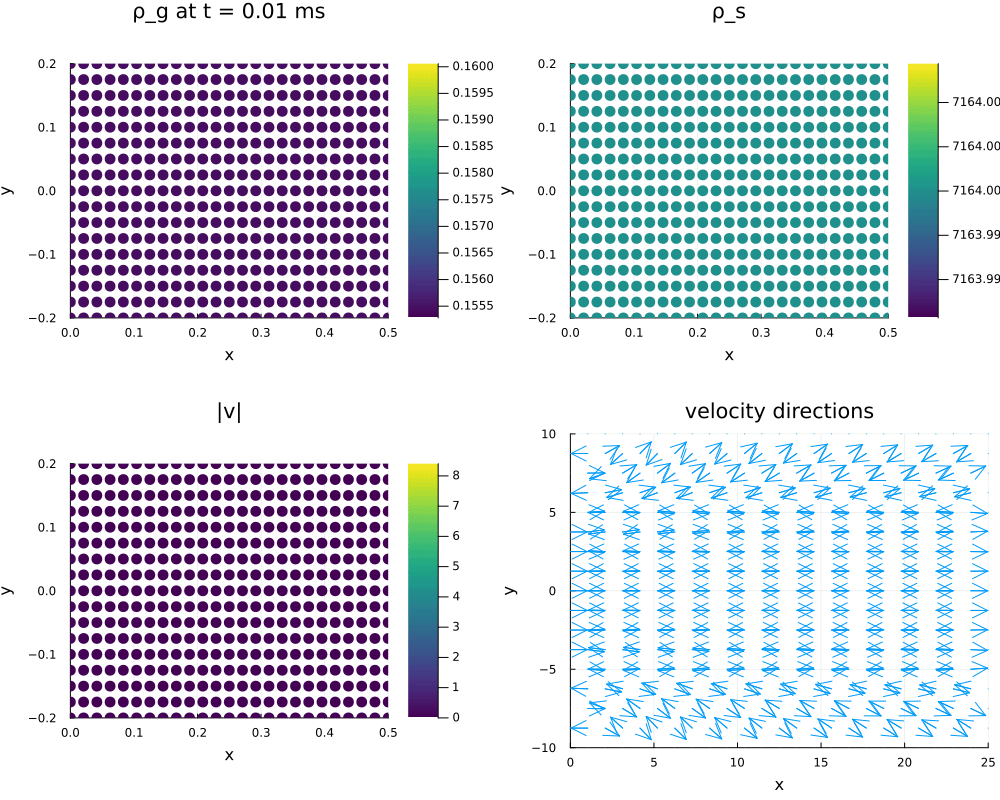

In [230]:
foldername = "x. bug finding"
gif(anim, joinpath(foldername, "23212413tau1.gif"), fps=20)

In [ ]:

# coordinates of grid nodes
xs = [node.x[1] for node in getnodes(grid)]
ys = [node.x[2] for node in getnodes(grid)]

# helper for safe color limits
function safe_clims(vmin, vmax)
    if isapprox(vmin, vmax; rtol=1e-8, atol=1e-11)
        δ = max(abs(vmin), 1.0) * 1e-6
        return (vmin - δ, vmax + δ)
    else
        return (vmin, vmax)
    end
end

# compute global plotting limits
rho_min  = Inf
rho_max  = -Inf
rhos_min = Inf
rhos_max = -Inf
vmag_min = Inf
vmag_max = -Inf

for uk in sol.u
    rho_nodes  = evaluate_at_grid_nodes(dh, uk, :rho)
    rhos_nodes = evaluate_at_grid_nodes(dh, uk, :rho_s)
    v_nodes    = evaluate_at_grid_nodes(dh, uk, :v)

    vmag_nodes = [norm(v) for v in v_nodes]

    rho_min  = min(rho_min, minimum(rho_nodes))
    rho_max  = max(rho_max, maximum(rho_nodes))

    rhos_min = min(rhos_min, minimum(rhos_nodes))
    rhos_max = max(rhos_max, maximum(rhos_nodes))

    vmag_min = min(vmag_min, minimum(vmag_nodes))
    vmag_max = max(vmag_max, maximum(vmag_nodes))
end

rho_clims  = safe_clims(rho_min, rho_max)
rhos_clims = safe_clims(rhos_min, rhos_max)
vmag_clims = safe_clims(vmag_min, vmag_max)

# optional: subsample arrows for quiver plot
# if too many arrows, increase skip
skip = 1
arrow_inds = collect(1:skip:length(xs))

s = 50

anim = @animate for k in 2:length(sol.t) #eachindex(sol.t)

    rho_nodes  = evaluate_at_grid_nodes(dh, sol.u[k], :rho)
    rhos_nodes = evaluate_at_grid_nodes(dh, sol.u[k], :rho_s)
    v_nodes    = evaluate_at_grid_nodes(dh, sol.u[k], :v)

    vx = [v[1] for v in v_nodes]
    vy = [v[2] for v in v_nodes]
    vmag_nodes = [norm(v) for v in v_nodes]

    vx_dir = zeros(length(vx))
    vy_dir = zeros(length(vy))

    for i in eachindex(vx)
        vn = sqrt(vx[i]^2 + vy[i]^2)
        if vn > 1e-12
            vx_dir[i] = vx[i] / vn
            vy_dir[i] = vy[i] / vn
        end
    end

    # top-left: rho_g
    p1 = scatter(
        xs,
        ys,
        marker_z = rho_nodes,
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = rho_clims,
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title = "ρ_g at t = $(round(1000 * sol.t[k], digits=5)) ms",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w),
    )

    # top-right: rho_s
    p2 = scatter(
        xs,
        ys,
        marker_z = rhos_nodes,
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = rhos_clims,
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title = "ρ_s",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w),
    )

    # bottom-left: velocity magnitude
    p3 = scatter(
        xs,
        ys,
        marker_z = vmag_nodes,
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = vmag_clims,
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title = "|v|",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w),
    )

    # bottom-right: velocity directions
    p4 = quiver(
        s*xs,
        s*ys,
        quiver = (vx_dir, vy_dir),
        xlabel = "x",
        ylabel = "y",
        title = "velocity directions",
        legend = false,
        xlims = (0, s*L),
        ylims = (-s*w, s*w),
    )

    plot(p1, p2, p3, p4, layout = (2, 2), size = (1000, 800))
    println("Frame $(k) of $(length(sol.t))")
end

Frame 2 of 101
Frame 3 of 101
Frame 4 of 101
Frame 5 of 101
Frame 6 of 101
Frame 7 of 101
Frame 8 of 101
Frame 9 of 101
Frame 10 of 101
Frame 11 of 101
Frame 12 of 101
Frame 13 of 101
Frame 14 of 101
Frame 15 of 101
Frame 16 of 101
Frame 17 of 101
Frame 18 of 101
Frame 19 of 101
Frame 20 of 101
Frame 21 of 101
Frame 22 of 101
Frame 23 of 101
Frame 24 of 101
Frame 25 of 101
Frame 26 of 101
Frame 27 of 101
Frame 28 of 101
Frame 29 of 101
Frame 30 of 101
Frame 31 of 101
Frame 32 of 101
Frame 33 of 101
Frame 34 of 101
Frame 35 of 101
Frame 36 of 101
Frame 37 of 101
Frame 38 of 101
Frame 39 of 101
Frame 40 of 101
Frame 41 of 101
Frame 42 of 101
Frame 43 of 101
Frame 44 of 101
Frame 45 of 101
Frame 46 of 101
Frame 47 of 101
Frame 48 of 101
Frame 49 of 101
Frame 50 of 101
Frame 51 of 101
Frame 52 of 101
Frame 53 of 101
Frame 54 of 101
Frame 55 of 101
Frame 56 of 101
Frame 57 of 101
Frame 58 of 101
Frame 59 of 101
Frame 60 of 101
Frame 61 of 101
Frame 62 of 101
Frame 63 of 101
Frame 64 of 101


Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_h2aif7", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000091.png", "000092.png", "000093.png", "000094.png", "000095.png", "000096.png", "000097.png", "000098.png", "000099.png", "000100.png"])

In [102]:
# double gif plot
foldername = name

U = Array(sol)

xs = [node.x[1] for node in getnodes(grid)]
ys = [node.x[2] for node in getnodes(grid)]

sol_v = U[v_global, :]
sol_ρ = U[rho_global, :]
sol_ρ_s = U[rho_s_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = sol.t #range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρmax = maximum(sol_ρ)
ρmin = minimum(sol_ρ)

rhosmin = minimum(sol_ρ_s)
rhosmax = maximum(sol_ρ_s)

vmax = maximum(sol_v)
vmin = minimum(sol_v)

anim = @animate for k in 1:length(sol.t)-2

    p1 = scatter(
        xs, ys,
        marker_z = sol_ρ[:, k],
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = (ρmin, ρmax),
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title="ρ_g at t = $(round(1000*discrete_t[k], digits=5))ms",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w)
    )

    p2 = scatter(
        xs, ys,
        marker_z = sol_ρ_s[:, k],
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = (rhosmin, rhosmax),
        xlabel = "x",
        ylabel = "y",
        title = "ρ_s",
        aspect_ratio = :equal,
        xlims = (0, L),
        ylims = (-w, w),
        legend = false
    )

    plot(p1, p2, layout=(2,1), size=(800,600))
end

GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is inval

Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_9Mztuk", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000064.png", "000065.png", "000066.png", "000067.png", "000068.png", "000069.png", "000070.png", "000071.png", "000072.png", "000073.png"])

# debugging and code analysis

In [220]:
@benchmark assemble_rhs!(
    $params.rhs, $u, $params)

BenchmarkTools.Trial: 1936 samples with 1 evaluation per sample.
 Range (min … max):  2.113 ms … 44.489 ms  ┊ GC (min … max): 0.00% … 92.50%
 Time  (median):     2.333 ms              ┊ GC (median):    0.00%
 Time  (mean ± σ):   2.563 ms ±  1.199 ms  ┊ GC (mean ± σ):  0.83% ±  2.10%

  ▄█▂▁▁                                                       
  █████▇▅▅▄▄▃▃▃▃▃▃▃▂▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▁▂▂▂▂▁▂▂▂ ▃
  2.11 ms        Histogram: frequency by time        5.53 ms <

 Memory estimate: 133.85 KiB, allocs estimate: 2314.

In [221]:
@code_warntype assemble_rhs!(params.rhs, u, params)

MethodInstance for assemble_rhs!(::Vector{Float64}, ::Vector{Float64}, ::RHSparams{DofHandler{2, Grid{2, Quadrilateral, Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, VectorizedInterpolation{2, RefQuadrilateral, 1, Lagrange{RefQuadrilateral, 1}}, Matrix{Vec{2, Float64}}, Matrix{Tens

In [222]:
@code_warntype assemble_mass!(
    params.M, u, params
)

MethodInstance for assemble_mass!(::SparseMatrixCSC{Float64, Int64}, ::Vector{Float64}, ::RHSparams{DofHandler{2, Grid{2, Quadrilateral, Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}, CellValues{Ferrite.FunctionValues{1, VectorizedInterpolation{2, RefQuadrilateral, 1, Lagrange{RefQuadrilateral, 1}}, Matrix{Vec{2, Float

In [223]:
@benchmark assemble_mass!(
    $params.M, $u, $params
)

BenchmarkTools.Trial: 3002 samples with 1 evaluation per sample.
 Range (min … max):  1.384 ms …   9.089 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     1.534 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   1.655 ms ± 413.588 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ███▇▇▇▆▆▅▄▄▃▃▂▂▂▁▁▁ ▁▁ ▁                                    ▂
  ███████████████████▇████▆▇▇▇▇▇▅▅▆▆▅▆▇▇▆▅▇▅▆▅▇▅▇▁▇▅▅▆▅▅▅▅▇▆▅ █
  1.38 ms      Histogram: log(frequency) by time      3.46 ms <

 Memory estimate: 3.43 KiB, allocs estimate: 22.

In [60]:
getfacetset(grid, "left_slit")

OrderedCollections.OrderedSet{FacetIndex} with 6 elements:
  FacetIndex((121, 4))
  FacetIndex((145, 4))
  FacetIndex((169, 4))
  FacetIndex((193, 4))
  FacetIndex((217, 4))
  FacetIndex((241, 4))

In [ ]:
# We calculate the FE integration weights for rho_s.
#
# The mass matrix is:
#
#     M_ij = ∫ phi_i * phi_j dx
#
# Multiplying it by a vector of ones gives:
#
#     b_i = Σ_j M_ij = ∫ phi_i dx
#
# which is the correct FE weight for integrating the solution:
#
#     ∫ rho_s dx ≈ b ⋅ rho_s
#
# This automatically handles the dx/2 boundary contributions
# for P1 elements and also works for nonuniform meshes.
M_rho_s = ML[rho_s_global, rho_s_global]
mass_weights_rho_s = M_rho_s * ones(length(rho_s_global))


# Calculate total absorbed amount at every saved timestep
absorbed_mass = zeros(size(sol_ρ_s, 2))

for k in axes(sol_ρ_s, 2)

    # FE approximation of:
    #
    #     M_s(t) = ∫ rho_s(x,t) dx
    #
    absorbed_mass[k] = dot(mass_weights_rho_s, sol_ρ_s[:, k])

end


# Maximum possible absorbed mass:
#
#     M_sat = ∫ rho_sat dx = rho_sat * L
#
# Here L = 1, but keeping the formula general.

maximum_mass = rho_sat * 1.0


# Fraction of solid capacity filled
fill_fraction = absorbed_mass ./ maximum_mass


# Plot filling fraction versus time
plot(
    discrete_t,
    fill_fraction,
    xlabel = "time",
    ylabel = "fraction filled",
    label = "solid saturation",
)

In [ ]:
plot(
    sol.t,
    sol_ρ_s[1, :],
    xlabel = "time (s)",
    ylabel = "saturation",
    label = "saturation at x=0",
    legend=:bottomright
)
k = log(2)/(1-ϵ)
plot!(
    sol.t,
    1.0 .- 1 .* exp.(-k.*sol.t),
    label = "analytical solution at x=0",
    linestyle = :dash
)

plot!(
    sol.t,
    fill_fraction/(1-ϵ),
    # xlabel = "time",
    # ylabel = "fraction filled",
    label = "full solid saturation"
    )

plot!(
    sol.t,
    sol_ρ_s[end, :],
    # xlabel = "time",
    # ylabel = "solid density [kg/m^3]",
    label = "saturation at x=L"
)


In [ ]:
savefig(joinpath(foldername, "fill_fraction total pressure.png"))

In [ ]:
# report_figures_folder = "..\\report\\figures\\"
# folder = mkpath(report_figures_folder)
# name = "A.png"
# savefig(joinpath(folder, name))